# 05 · Modelo: XGBoost

**Proyecto Final — Machine Learning y Deep Learning**

Este notebook se centra en **un solo modelo**: **boosting** de árboles; el rey de los datos tabulares (y nuestro mejor modelo). Sigue la misma estructura que el resto de notebooks de modelo, para poder compararlos con facilidad.

> 📖 Términos técnicos explicados en `docs/glosario.md`. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb); la comparación de todos los modelos, en [`07_comparativa_modelos.ipynb`](07_comparativa_modelos.ipynb).

## 1. Cómo funciona

**XGBoost** es *gradient boosting*: entrena árboles **en secuencia**, y cada árbol nuevo se centra en **corregir los errores** del conjunto anterior (ajusta los gradientes del error). Combinando muchos árboles "débiles" obtiene un modelo **fuerte**.

A diferencia del Random Forest (árboles independientes que se promedian), aquí los árboles se construyen **uno tras otro** mejorando lo anterior. Incluye **regularización** integrada y suele ser el **mejor** en datos tabulares — como ocurre en este proyecto.

## 2. Los datos

Usamos el **mismo preprocesado compartido** por todos los modelos (`src/preprocessing.py`): imputación de huecos, estandarización de las numéricas y *one-hot* de las categóricas. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb). Cargamos y dividimos en train/test (estratificado, semilla fija) con `load_and_prepare()`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.pipeline import Pipeline
from src import config
from src.data_loader import load_and_prepare
from src.preprocessing import build_preprocessor
from src.notebook_utils import evaluar, plot_confusion_roc  # lógica compartida
from src.model_viz import visualizar_modelo

X_train, X_test, y_train, y_test = load_and_prepare()
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (95368, 28) | Prueba: (23842, 28)


## 3. Los hiperparámetros: ¿qué controla cada uno?

Los **hiperparámetros** son los ajustes que fijamos *antes* de entrenar (no se aprenden de los datos). Estos son los principales de este modelo:

| Hiperparámetro | Qué controla |
|---|---|
| `n_estimators` | Nº de árboles (rondas de boosting). |
| `learning_rate` | Cuánto aporta cada árbol. Bajo → aprendizaje lento pero más fino (necesita más árboles). |
| `max_depth` | Profundidad de cada árbol (complejidad e interacciones que capta). |
| `subsample` | Fracción de **filas** por árbol (regularización tipo *bagging*). |
| `colsample_bytree` | Fracción de **columnas** por árbol. |
| `min_child_weight` / `gamma` / `reg_lambda` | Parámetros de **regularización** que frenan el sobreajuste. |

## 4. Entrenamiento y evaluación (parámetros base)

Entrenamos el modelo con los hiperparámetros base y lo evaluamos sobre el conjunto de prueba (datos que no vio al entrenar).

In [2]:
# Pipeline = preprocesado + modelo (con los hiperparámetros base del proyecto)
from xgboost import XGBClassifier
modelo = Pipeline([('preprocessor', build_preprocessor()), ('model', XGBClassifier(**config.XGBOOST_PARAMS))])
modelo.fit(X_train, y_train)
auc_base = evaluar(modelo, X_test, y_test, 'Base')

Base         | accuracy=0.8826 | precision=0.8575 | recall=0.8195 | f1=0.8380 | roc_auc=0.9548


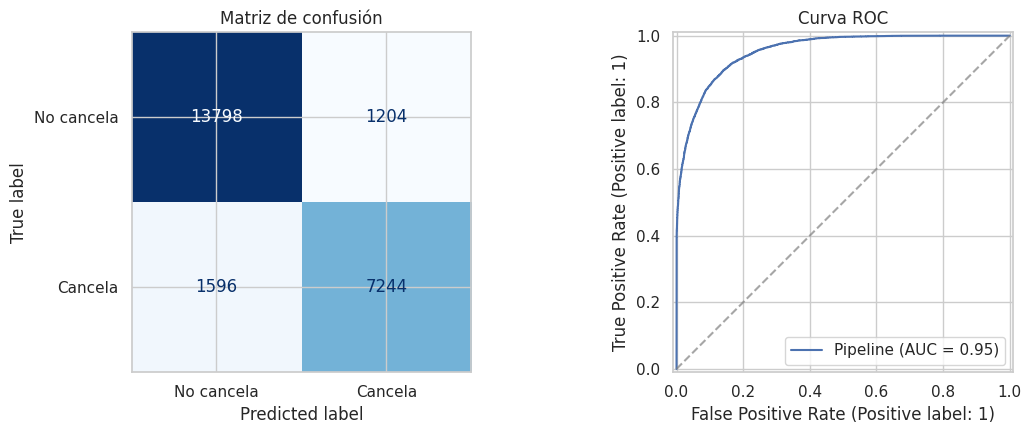

In [3]:
# Matriz de confusión y curva ROC (helper compartido en src/notebook_utils.py)
plot_confusion_roc(modelo, X_test, y_test)

## 5. Visualización del modelo

Visualizamos la **importancia de variables**. El modelo son ~cientos de árboles encadenados, así que no se dibuja entero; la importancia resume en qué se apoya. (lo dibuja `src/model_viz.py`, que elige la representación adecuada según el tipo de modelo).

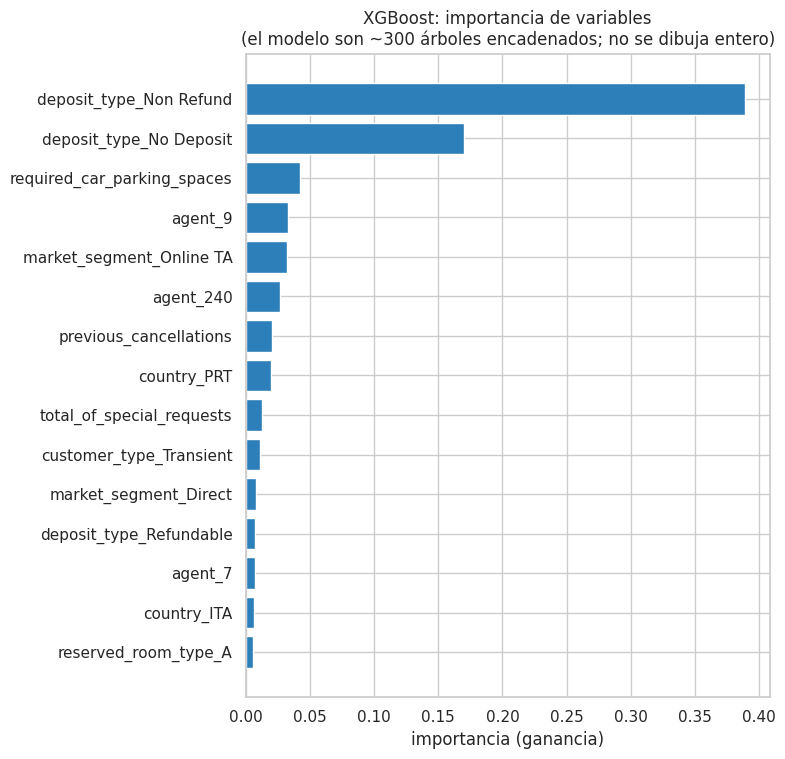

In [4]:
visualizar_modelo(modelo, X_train)  # dibuja lo adecuado según el tipo de modelo

## 6. Optimización de hiperparámetros

Buscamos la mejor combinación con **RandomizedSearchCV (muestreo aleatorio de combinaciones)**, optimizando **ROC-AUC** por validación cruzada. (Es el mismo procedimiento, por modelo, que automatiza `src/tuning.py` para todo el proyecto.)

In [5]:
from sklearn.model_selection import RandomizedSearchCV

base_pipe = Pipeline([('preprocessor', build_preprocessor()), ('model', XGBClassifier(random_state=config.RANDOM_STATE, n_jobs=-1, eval_metric='logloss'))])
busqueda = RandomizedSearchCV(base_pipe, config.XGBOOST_GRID, n_iter=config.TUNING_N_ITER, scoring='roc_auc', cv=config.TUNING_CV_FOLDS, n_jobs=-1, random_state=config.RANDOM_STATE)
busqueda.fit(X_train, y_train)
print('Mejores hiperparámetros:', busqueda.best_params_)
print(f'ROC-AUC (validación cruzada, {config.TUNING_CV_FOLDS} folds): {busqueda.best_score_:.4f}')

Mejores hiperparámetros: {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 8, 'model__learning_rate': 0.2, 'model__colsample_bytree': 1.0}
ROC-AUC (validación cruzada, 3 folds): 0.9580


## 7. Resultado final y cuándo usar este modelo

Comparamos el rendimiento en test **antes y después** de optimizar:

In [6]:
auc_tuned = evaluar(busqueda.best_estimator_, X_test, y_test, 'Optimizado')
print(f'\nROC-AUC en test:  base {auc_base:.4f}  ->  optimizado {auc_tuned:.4f}')

Optimizado   | accuracy=0.8925 | precision=0.8680 | recall=0.8376 | f1=0.8525 | roc_auc=0.9603

ROC-AUC en test:  base 0.9548  ->  optimizado 0.9603


**Cuándo conviene:** cuando buscas **el máximo rendimiento** en datos tabulares. Es el modelo elegido del proyecto (mejor ROC-AUC). A cambio, tiene **más hiperparámetros** que ajustar.